In [1]:
import random

import numpy as np
import matplotlib.pyplot as plt

import torch
from torch import nn

from IPython.display import clear_output

# LinearRegression from Scratch

In [2]:
class BaseData:
    def __init__(self):
        pass

    def get_dataloader(self, train):
        raise NotImplementedError

    def train_dataloader(self):
        return self.get_dataloader(True)

    def val_dataloader(self):
        return self.get_dataloader(False)

class SyntheticRegressionData(BaseData):
    def __init__(self, w, b, noise=0.01, num_train=1200, num_val=800, batch_size=32):
        super().__init__()
        
        self.w = w
        self.b = b
        self.noise = noise
        self.num_train = num_train
        self.num_val = num_val
        self.batch_size = batch_size
        
        self.n = num_train + num_val
        self.d = len(w)

        self.X = torch.randn(self.n, self.d)
        e = torch.randn(self.n, 1) * self.noise

        self.y = (self.X @ self.w.reshape((-1, 1))) + self.b + e

    def get_dataloader(self, train):
        indices = slice(0, self.num_train) if train else slice(self.num_train, self.n)
        
        return self._get_tensorloader(train, indices=indices)

    def _get_tensorloader(self, train, indices=slice(0, None)):
        dataset = torch.utils.data.TensorDataset(self.X[indices], self.y[indices])
        
        return torch.utils.data.DataLoader(dataset, self.batch_size, shuffle=train)

In [3]:
class BaseOptimizer:
    def __init__(self, params, lr):
        self.params = params
        self.lr = lr

    def step(self):
        raise NotImplementedError

    def zero_grad(self):
        raise NotImplementedError

class SGD(BaseOptimizer):
    def __init__(self, params, lr):
        super().__init__(params, lr)

    def step(self):
        for p in self.params:
            p -= self.lr * p.grad

    def zero_grad(self):
        for p in self.params:
            if p.grad is not None:
                p.grad.zero_()

In [4]:
class BaseModel:
    def __init__(self, model):
        self.model = model

        self.trainer = None

    def __call__(self, X):
        return self.forward(X)

    def forward(self, X):
        raise NotImplementedError

    def loss(self, y_hat, y):
        raise NotImplementedError

    def configure_optimizers(self):
        raise NotImplementedError

    def training_step(self, batch):
        y = batch[-1]
        y_hat = self.model(*batch[:-1])
        
        return self.loss(y_hat, y)

    def validation_step(self, batch):
        y = batch[-1]
        y_hat = self.model(*batch[:-1])
        
        return self.loss(y_hat, y)

class LinearRegressionScratch(BaseModel):
    def __init__(self, num_inputs, lr, sigma=0.01):
        super().__init__(self)
        
        self.num_inputs = num_inputs
        self.lr = lr
        self.sigma = sigma
        
        self.w = torch.normal(0, sigma, (num_inputs, 1), requires_grad=True)
        self.b = torch.zeros(1, requires_grad=True)

    def forward(self, X):
        return (X @ self.w) + self.b

    def loss(self, y_hat, y):
        l = ((y_hat - y) ** 2) / 2
        
        return l.mean()

    def configure_optimizers(self):
        return SGD([self.w, self.b], self.lr)

In [5]:
class Trainer:
    def __init__(self, max_epochs):
        self.max_epochs = max_epochs
        
        self.train_dataloader = None
        self.val_dataloader = None
        self.num_train_batches = None
        self.num_val_batches = None

        self.model = None
        self.optim = None

        self.epoch = 0
        self.train_batch_idx = 0
        self.val_batch_idx = 0

        self.train_losses = []
        self.val_losses = []

    def prepare_data(self, data):
        self.train_dataloader = data.train_dataloader()
        self.num_train_batches = len(self.train_dataloader)
        
        self.val_dataloader = data.val_dataloader()
        self.num_val_batches = (
            len(self.val_dataloader)
            if self.val_dataloader
            else 0
        )

    def prepare_model(self, model):
        model.trainer = self
        self.model = model

    def prepare_batch(self, batch):
        return batch

    def fit_epoch(self):
        train_loss = 0.0
    
        for batch in self.train_dataloader:
            loss = self.model.training_step(
                self.prepare_batch(batch)
            )
    
            self.optim.zero_grad()
            loss.backward()
    
            with torch.no_grad():
                self.optim.step()
    
            train_loss += loss.item()
            self.train_batch_idx += 1
    
        train_loss /= len(self.train_dataloader)
        self.train_losses.append(train_loss)
    
        if not self.val_dataloader:
            self.plot()
            
            print(
                f'Epoch {self.epoch + 1}/{self.max_epochs} '
                f'| train_loss: {train_loss:.6f}'
            )
            return
    
        val_loss = 0.0
    
        with torch.no_grad():
            for batch in self.val_dataloader:
                loss = self.model.validation_step(
                    self.prepare_batch(batch)
                )
    
                val_loss += loss.item()
                self.val_batch_idx += 1
    
        val_loss /= len(self.val_dataloader)
        self.val_losses.append(val_loss)

        self.plot()
    
        print(
            f'Epoch {self.epoch + 1}/{self.max_epochs} '
            f'| train_loss: {train_loss:.6f} '
            f'| val_loss: {val_loss:.6f}'
        )

    def plot(self):
        clear_output(wait=True)
        
        plt.figure(figsize=(7, 4))
        plt.plot(self.train_losses, label='Train loss')
        plt.plot(self.val_losses, label='Validation loss')
        
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(True)
        plt.show()

    def fit(self, model, data):
        self.prepare_data(data)
        self.prepare_model(model)
        
        self.optim = model.configure_optimizers()

        self.epoch = 0
        self.train_batch_idx = 0
        self.val_batch_idx = 0

        self.train_losses = []
        self.val_losses = []

        for self.epoch in range(self.max_epochs):
            self.fit_epoch()

## Prepare Dataset
- Load/Synthesize Data
- Train/Val Batch Split

In [6]:
w = torch.tensor([2, -3.4])
b = 4.2

data = SyntheticRegressionData(w, b)

train_batches = data.get_dataloader(True)
val_batches = data.get_dataloader(False)

len(train_batches), len(val_batches)

(38, 25)

## Training

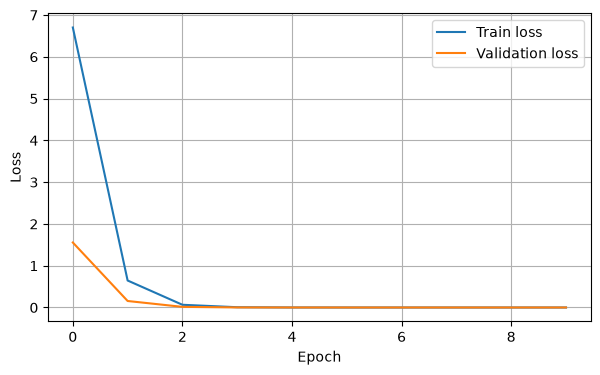

Epoch 10/10 | train_loss: 0.000048 | val_loss: 0.000049


In [7]:
num_inputs = len(w)
model = LinearRegressionScratch(num_inputs, 0.03)

trainer = Trainer(max_epochs=10)
trainer.fit(model, data)

In [8]:
with torch.no_grad():
    print(f'error in estimating w: {data.w - model.w.reshape(data.w.shape)}')
    print(f'error in estimating b: {data.b - model.b}')

error in estimating w: tensor([-0.0002, -0.0002])
error in estimating b: tensor([-0.0001])


In [9]:
with torch.no_grad():
    print(f'Original w: {[i.item() for i in data.w]}')
    print(f'Model w: {[i.item() for i in model.w]}')
    print(f'Original b: {data.b}')
    print(f'Model b: {model.b.item()}')

Original w: [2.0, -3.4000000953674316]
Model w: [2.000229597091675, -3.39977765083313]
Original b: 4.2
Model b: 4.200114727020264


## Inference

In [10]:
val_batch = next(iter(val_batches))
X, y = val_batch[0], val_batch[1]

with torch.no_grad():
    y_hat = model(X)
    print(f'Input features: {[x.item() for x in X[0]]}')
    print(f'Target: \n- Actual: {y[0].item()} \n- Predicted: {y_hat[0].item()}')

Input features: [0.5384629964828491, -1.0978589057922363]
Target: 
- Actual: 9.000685691833496 
- Predicted: 9.00964069366455


# LinearRegression using PyTorch

In [11]:
class LinearRegression(BaseModel):
    def __init__(self, lr, sigma=0.01):
        super().__init__(nn.LazyLinear(1))

        self.lr = lr

        self.model.weight.data.normal_(0, sigma)
        self.model.bias.data.fill_(0)

    def parameters(self):
        return self.model.parameters()

    def forward(self, X):
        return self.model(X)

    def loss(self, y_hat, y):
        return nn.functional.mse_loss(y_hat, y)

    def configure_optimizers(self):
        return torch.optim.SGD(self.parameters(), self.lr)

    def get_w_b(self):
        return self.model.weight.detach(), self.model.bias.detach()

## Training

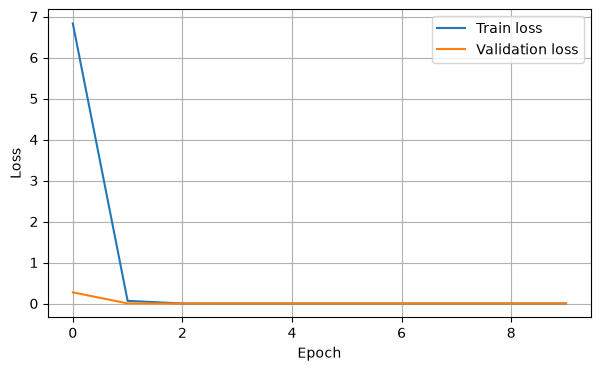

Epoch 10/10 | train_loss: 0.000098 | val_loss: 0.000098


In [12]:
model = LinearRegression(lr=0.03)

trainer = Trainer(max_epochs=10)
trainer.fit(model, data)

In [13]:
model_w, model_b = model.get_w_b()

with torch.no_grad():
    print(f'error in estimating w: {data.w - model_w.reshape(data.w.shape)}')
    print(f'error in estimating b: {data.b - model_b}')

error in estimating w: tensor([ 5.4002e-05, -3.1447e-04])
error in estimating b: tensor([2.5272e-05])


In [16]:
with torch.no_grad():
    print(f'Original w: {[i.item() for i in data.w]}')
    print(f'Model w: {[i.item() for i in model_w[0]]}')
    print(f'Original b: {data.b}')
    print(f'Model b: {model_b.item()}')

Original w: [2.0, -3.4000000953674316]
Model w: [1.9999459981918335, -3.3996856212615967]
Original b: 4.2
Model b: 4.199974536895752


## Inference

In [15]:
val_batch = next(iter(val_batches))
X, y = val_batch[0], val_batch[1]

with torch.no_grad():
    y_hat = model(X)
    print(f'Input features: {[x.item() for x in X[0]]}')
    print(f'Target: \n- Actual: {y[0].item()} \n- Predicted: {y_hat[0].item()}')

Input features: [0.5384629964828491, -1.0978589057922363]
Target: 
- Actual: 9.000685691833496 
- Predicted: 9.009246826171875
